In [1]:

import os
import sys
import pickle
import time
from pathlib import Path
from joblib import Parallel, delayed
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, StratifiedGroupKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    f1_score,
)
import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


sys.path.append("..")
from src import utils
sns.set_context("notebook")
RNG = 42
N_JOBS = -1
np.random.seed(RNG)
DATA_TAG = "medium"
PROJECT_ROOT = Path("../").resolve()
DATA_DIR     = PROJECT_ROOT / "data"
AUDIO_DIR    = DATA_DIR / "fma_medium"
METADATA_DIR = DATA_DIR / "fma_metadata"
MODELS_DIR = PROJECT_ROOT / "outputs/models"
OUTPUTS_DIR  = PROJECT_ROOT / "outputs"
X_PATH       = OUTPUTS_DIR / f"X_{DATA_TAG}.npy"
IDS_PATH      = OUTPUTS_DIR / f"track_ids_{DATA_TAG}.npy"
BAD_FILES_CSV = OUTPUTS_DIR / f"bad_files_{DATA_TAG}.csv"
DATASET_CSV   = OUTPUTS_DIR / f"features_with_genre_{DATA_TAG}.csv"

SR          = 22050      
DURATION    = 30.0
N_FFT       = 2048
HOP_LENGTH  = 512
N_MFCC      = 20
SAVE_EVERY  = 500

# Modeling params
TEST_SIZE = 0.2
KNN_K     = 5
KBEST_K   = 10
CV_FOLDS  = 5

In [2]:
tracks = utils.load(METADATA_DIR / "tracks.csv")
in_medium = tracks[("set","subset")] <= "medium"
has_genre = tracks[("track", "genre_top")].notna()
subset_df = tracks[in_medium & has_genre]

genre_labels = (
    subset_df[("track", "genre_top")]
    .astype(str)
    .rename("genre")
    .to_frame()
)
genre_labels.index.name = "track_id"

SUBSET_TRACK_IDS = np.asarray(genre_labels.index, dtype=np.int32)

print(f"Distinct genre_top classes: {genre_labels['genre'].nunique()}")
genre_labels["genre"].value_counts()

Distinct genre_top classes: 16


genre
Rock                   7103
Electronic             6314
Experimental           2251
Hip-Hop                2201
Folk                   1519
Instrumental           1350
Pop                    1186
International          1018
Classical               619
Old-Time / Historic     510
Jazz                    384
Country                 178
Soul-RnB                154
Spoken                  118
Blues                    74
Easy Listening           21
Name: count, dtype: int64

In [3]:
def summarize(features: np.ndarray) -> np.ndarray:
    feat = np.atleast_2d(features)
    return np.concatenate([feat.mean(axis=1), feat.std(axis=1)])

def extract_features(y: np.ndarray, sr: int) -> np.ndarray:
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    centroid  = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    contrast  = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    zcr       = librosa.feature.zero_crossing_rate(y)
    chroma    = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)

    return np.concatenate([
        summarize(mfcc),
        summarize(centroid),
        summarize(bandwidth),
        summarize(contrast),
        summarize(zcr),
        summarize(chroma),
    ]).astype(np.float32)

def _extract_one(tid:int):
    import os
    import librosa
    # Must run *inside the worker*, before librosa does BLAS-heavy work.
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    os.environ["NUMBA_NUM_THREADS"] = "1"
    audio_path = utils.get_audio_path(str(AUDIO_DIR), tid)
    try:
        y, sr = librosa.load(audio_path, sr=SR, duration=DURATION)
        if y is None or len(y) < sr:
            raise ValueError("Audio file too short")
        return tid, extract_features(y,sr), None
    except Exception as e:
        return tid, None, (audio_path, repr(e))


def run_extraction(target_track_ids: np.ndarray):
    X, ids, bad = [],[],[]
    todo = [int(t) for t in target_track_ids]
    print(f"Extracting features for {len(todo):,} tracks (n_jobs={N_JOBS})") 

    results = Parallel(n_jobs=N_JOBS, backend="loky", return_as="generator")(
        delayed(_extract_one)(tid) for tid in todo
    )

    for tid, feat, err in tqdm(results ,total=len(todo), desc="Features"):
        if err is not None:
            bad.append(err)
            continue
        X.append(feat)
        ids.append(tid)
    
    X = np.asarray(X, dtype=np.float32)
    ids = np.asarray(ids, dtype=np.int32)
    np.save(X_PATH,   X)
    np.save(IDS_PATH, ids)
    if bad:
        pd.DataFrame(bad, columns=["path", "error"]).to_csv(BAD_FILES_CSV, index=False)
    print(f"Extracted {len(X):,} tracks (skipped {len(bad):,}).")
    print(bad[:3])
    return X, ids
    
X_raw, track_ids = run_extraction(SUBSET_TRACK_IDS)

Extracting features for 25,000 tracks (n_jobs=-1)


Features:   0%|          | 0/25000 [00:01<?, ?it/s]


KeyboardInterrupt: 

In [4]:
def feature_column_names() -> list[str]:
    names = []
    names += [f"mfcc_{i+1}_mean" for i in range(N_MFCC)] + [f"mfcc_{i+1}_std" for i in range(N_MFCC)]
    names += ["centroid_mean",  "centroid_std"]
    names += ["bandwidth_mean", "bandwidth_std"]
    names += [f"contrast_{i+1}_mean" for i in range(7)] + [f"contrast_{i+1}_std" for i in range(7)]
    names += ["zcr_mean", "zcr_std"]
    names += [f"chroma_{i+1}_mean" for i in range(12)] + [f"chroma_{i+1}_std" for i in range(12)]
    return names

Xcache = np.load(OUTPUTS_DIR/"X_medium.npy")
idCache = np.load(OUTPUTS_DIR/"track_ids_medium.npy")
if X_PATH.exists():
    X_raw = Xcache
    track_ids = idCache

feature_cols = feature_column_names()
assert len(feature_cols) == X_raw.shape[1], (len(feature_cols), X_raw.shape[1])

features_df = pd.DataFrame(X_raw, columns=feature_cols)
features_df["track_id"] = track_ids

dataset = features_df.merge(genre_labels.reset_index(), on="track_id", how="inner")
dataset.to_csv(DATASET_CSV, index=False)

X = dataset[feature_cols].to_numpy()
y = dataset["genre"].to_numpy()


print(f"Matched tracks with features + genre: {len(dataset):,}")
print(f"Feature matrix: {X.shape} | classes: {len(np.unique(y))}")
dataset.head()

Matched tracks with features + genre: 24,984
Feature matrix: (24984, 84) | classes: 16


,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,...,chroma_5_std,chroma_6_std,chroma_7_std,chroma_8_std,chroma_9_std,chroma_10_std,chroma_11_std,chroma_12_std,track_id,genre
0,-66.780693,64.261795,-9.776764,11.287591,-2.419144,9.037897,-1.113319,4.549840,-5.305121,0.244527,...,0.213145,0.218078,0.221976,0.283803,0.271485,0.280620,0.263534,0.276085,2,Hip-Hop
1,-97.361130,72.045883,-3.167418,29.222960,5.950190,11.711256,-3.581754,6.233585,-7.438054,6.449967,...,0.233348,0.225914,0.232813,0.316618,0.296408,0.286979,0.304936,0.271281,3,Hip-Hop
2,-105.963890,86.369484,13.001237,23.292448,-0.144228,11.994685,-4.714581,16.547112,-5.426198,-0.890858,...,0.256733,0.267373,0.285289,0.283356,0.329748,0.324945,0.319172,0.309593,5,Hip-Hop
3,-16.811268,93.612061,-47.824646,31.577908,-3.762671,1.410515,-1.508164,1.884860,-4.522624,-0.247139,...,0.144595,0.171947,0.288188,0.173736,0.273143,0.210972,0.284800,0.196234,10,Pop
4,-83.633720,83.624977,-1.502812,33.663486,5.695960,7.583478,4.808328,19.052254,1.597538,10.050009,...,0.304273,0.280268,0.254635,0.275168,0.274611,0.281064,0.291817,0.275143,134,Hip-Hop


In [5]:
leftTable = pd.DataFrame({
    "track_id": tracks.index.astype(int),
    "artist_id": tracks[("artist", "id")].to_numpy(),          # already correct
    "fma_split": tracks[("set", "split")].astype(str).to_numpy(),  # already correct
})

leftTable

dataset = dataset.merge(leftTable, on="track_id", how="left")

# sanity checks — run these and read the output
print("rows:", len(dataset))
print("missing artist_id:", dataset["artist_id"].isna().sum())
print("missing fma_split:", dataset["fma_split"].isna().sum())
print("\nsplit sizes:")
print(dataset["fma_split"].value_counts())
print("\ngenres × split (counts):")
print(pd.crosstab(dataset["genre"], dataset["fma_split"]))
dataset[["track_id", "genre", "artist_id", "fma_split"]].head()


rows: 24984
missing artist_id: 0
missing fma_split: 0

split sizes:
fma_split
training      19908
test           2572
validation     2504
Name: count, dtype: int64

genres × split (counts):
fma_split            test  training  validation
genre                                          
Blues                   8        58           8
Classical              62       495          62
Country                18       142          18
Easy Listening          6        13           2
Electronic            632      5048         631
Experimental          225      1800         225
Folk                  152      1214         152
Hip-Hop               220      1756         220
Instrumental          174      1044         131
International         102       814         102
Jazz                   39       306          39
Old-Time / Historic    51       408          51
Pop                   119       945         122
Rock                  710      5677         711
Soul-RnB               42        94       

,track_id,genre,artist_id,fma_split
0,2,Hip-Hop,1,training
1,3,Hip-Hop,1,training
2,5,Hip-Hop,1,training
3,10,Pop,6,training
4,134,Hip-Hop,1,training


In [6]:
def overlap(df, split_col="fma_split"):
    train_artists = set(df.loc[df[split_col] == "training", "artist_id"])
    val_artists = set(df.loc[df[split_col] == "validation", "artist_id"])
    test_artists = set(df.loc[df[split_col] == "test", "artist_id"])

    pairs = {
        "trainnval": train_artists & val_artists,
        "trainntest": train_artists & test_artists,
        "valntest": val_artists & test_artists,
    }

    for name, overlap in pairs.items():
        print(f"{name}: {len(overlap)} artists")

    test_df = df[df[split_col] == "test"]
    leaked = test_df["artist_id"].isin(train_artists).sum()
    print(f"test tracks with artist also in train: {leaked} / {len(test_df)} "
        f"({leaked / len(test_df):.1%})")

overlap(dataset)

trainnval: 0 artists
trainntest: 0 artists
valntest: 0 artists
test tracks with artist also in train: 0 / 2572 (0.0%)


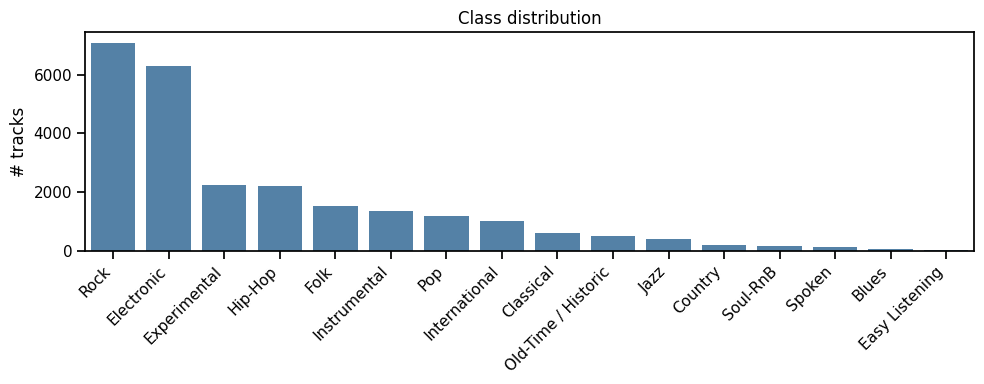

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
counts = dataset["genre"].value_counts()
sns.barplot(x=counts.index, y=counts.values, ax=ax, color="steelblue")
ax.set_title("Class distribution")
ax.set_ylabel("# tracks")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



In [8]:
train_mask = (dataset["fma_split"] == "training").to_numpy()
val_mask   = (dataset["fma_split"] == "validation").to_numpy()
test_mask  = (dataset["fma_split"] == "test").to_numpy()

Xtrain_raw, Ytrain = X[train_mask], y[train_mask],
Xval_raw, Yval = X[val_mask], y[val_mask],
Xtest_raw, Ytest = X[test_mask], y[test_mask]

scaler = StandardScaler().fit(Xtrain_raw)
Xtrain = scaler.transform(Xtrain_raw)
Xval   = scaler.transform(Xval_raw)
Xtest  = scaler.transform(Xtest_raw)
print(f"Train: {Xtrain.shape} | Val: {Xval.shape} | Test: {Xtest.shape}")


Train: (19908, 84) | Val: (2504, 84) | Test: (2572, 84)


In [9]:
# Model 1 - KNN
knnM1 = KNeighborsClassifier(n_neighbors=KNN_K)
knnM1.fit(Xtrain,Ytrain)

with open(MODELS_DIR / "finalized_model_M1.sav", "wb") as f:
    pickle.dump({"model": knnM1, "scaler": scaler, "features": feature_cols}, f)


In [10]:
# Model 2 - KNN on Top-10 Features (SelectKBest)
selector = SelectKBest(score_func=f_classif, k=KBEST_K).fit(Xtrain,Ytrain)
Xtrain_selector = selector.transform(Xtrain)
Xtest_selector = selector.transform(Xtest)
selected_cols = [c for c, keep in zip(feature_cols, selector.get_support()) if keep]
print("Selected Features: ", selected_cols)

selected_features_df = (
    pd.DataFrame({
        "feature": feature_cols,
        "f_score": selector.scores_,
        "p_value": selector.pvalues_,
        "selected": selector.get_support(),
    })
    .sort_values("f_score", ascending=False)
    .reset_index(drop=True)
)

selected_features_df.to_csv(OUTPUTS_DIR/"selected_features_top10.csv", index=False)

knnM2 = KNeighborsClassifier(n_neighbors=KNN_K)
knnM2.fit(Xtrain_selector,Ytrain)
with open(MODELS_DIR / "finalized_model_M2.sav", "wb") as f:
    pickle.dump(
        {"model": knnM2, "scaler": scaler, "selector": selector, "features": selected_cols},
        f,
    )


Selected Features:  ['mfcc_1_mean', 'mfcc_3_mean', 'mfcc_4_mean', 'mfcc_6_mean', 'centroid_std', 'bandwidth_mean', 'contrast_2_mean', 'contrast_3_mean', 'contrast_4_mean', 'contrast_5_mean']


In [ ]:
# Model 3 & 4 - Logistic Regression & Random Forest, LGBM & XGBoost
label_encoder = LabelEncoder()
Ytrain_encoded = label_encoder.fit_transform(Ytrain)
Ytest_encoded = label_encoder.transform(Ytest)

logreg = LogisticRegression(
    max_iter=2000,
    random_state=RNG,
    class_weight="balanced"
)
logreg.fit(Xtrain,Ytrain)

rf = RandomForestClassifier(
    n_estimators=300,
    n_jobs=1,
    class_weight="balanced"
)
rf.fit(Xtrain,Ytrain)

start = time.time()
xg = xgb.XGBClassifier(
    maxdepth=6, 
    learning_rate=0.05, 
    silent=1,
    eta=1,
    objective='multi:softprob',
    num_round=50,
    num_classes=len(label_encoder.classes_)
)

lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgbm.fit(Xtrain,Ytrain)
xg.fit(Xtrain,Ytrain_encoded)
ypred_encoded=xg.predict(Xtest) 
ypred_xgb = label_encoder.inverse_transform(
    ypred_encoded.astype(int)
)


with open(MODELS_DIR / "finalized_model_M3_logreg.sav", "wb") as f:
    pickle.dump({"model": logreg, "scaler": scaler, "features": feature_cols}, f)
with open(MODELS_DIR / "finalized_model_M4_rf.sav", "wb") as f:
    pickle.dump({"model": rf, "scaler": scaler, "features": feature_cols}, f)
with open(MODELS_DIR / "finalized_model_M4_Boost.sav", "wb") as f:
    pickle.dump({"model": xg, "scaler": scaler, "features": feature_cols}, f)


In [ ]:
# Model 5 - MLPClassifier (Small Neural Network)
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import LabelEncoder

class MLP(BaseEstimator, ClassifierMixin):
    """
    Thin wrapper around MLPClassifier that label-encodes string targets.
    """

    def __init__(self, **mlp_kwargs):
        self.mlp_kwargs = mlp_kwargs

    def fit(self,X,y):
        self.label_encoder = LabelEncoder().fit(y)
        self.mlp_ = MLPClassifier(**self.mlp_kwargs)
        self.mlp_.fit(X, self.label_encoder.transform(y))
        self.classes_ = self.label_encoder.classes_
        return self

    def predict(self,X):
        return self.label_encoder.inverse_transform(self.mlp_.predict(X))

    def predict_proba(self, X):
        return self.mlp_.predict_proba(X)

mlp = MLP(
    hidden_layer_sizes=(128,64),
    activation = "relu",
    solver="adam",
    alpha=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=RNG,
)
mlp.fit(Xtrain,Ytrain)

with open(MODELS_DIR / "finalized_model_M5_mlp.sav", "wb") as f:
    pickle.dump({"model": mlp, "scaler": scaler, "features": feature_cols}, f)

print(f"MLP converged in {mlp.mlp_.n_iter_} iterations | best validation score: {mlp.mlp_.best_validation_score_:.4f}")


MLP converged in 28 iterations | best validation score: 0.6288


In [ ]:
#Evaluation & Comparison

def evaluate(name,model,Xeval,Yeval):
    Ypred = model.predict(Xeval)
    acc = accuracy_score(Yeval,Ypred)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        Yeval, Ypred, average="macro", zero_division=0,
    )

    weighted_f1 = f1_score(Yeval, Ypred, average="weighted", zero_division=0)

    print(F"\n=== {name} - accuracy: {acc:.4f} | macro F1: {macro_f1:.4f} | weighted F1: {weighted_f1: .4f} ===")
    print(classification_report(Yeval, Ypred, zero_division=0))

    per_class = classification_report(
        Yeval, Ypred, zero_division=0, output_dict=True
    )

    return{
        "name": name,
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "Ypred": Ypred,
        "per_class": per_class
    }

results = [
    evaluate("M1 KNN (full)",     knnM1,  Xtest,     Ytest),
    evaluate("M2 KNN (top-10)",   knnM2,  Xtest_selector, Ytest),
    evaluate("M3 LogReg (full)",  logreg,  Xtest,     Ytest),
    evaluate("M4 RandomForest",   rf,      Xtest,     Ytest),
    evaluate("M5 MLP",            mlp,     Xtest,     Ytest),
    evaluate("XGBoost",            xg,     Xtest,     Ytest_encoded),
    evaluate("LightGradientBoostingModel", lgbm, Xtest, Ytest)
]




=== M1 KNN (full) - accuracy: 0.5035 | macro F1: 0.3013 | weighted F1:  0.4684 ===
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         8
          Classical       0.34      0.68      0.45        62
            Country       0.07      0.11      0.09        18
     Easy Listening       0.00      0.00      0.00         6
         Electronic       0.60      0.58      0.59       632
       Experimental       0.32      0.11      0.16       225
               Folk       0.20      0.28      0.23       152
            Hip-Hop       0.47      0.66      0.55       220
       Instrumental       0.25      0.07      0.12       174
      International       0.28      0.20      0.23       102
               Jazz       0.43      0.26      0.32        39
Old-Time / Historic       0.91      0.96      0.93        51
                Pop       0.12      0.06      0.08       119
               Rock       0.61      0.80      0.69       710


In [ ]:
# 5-fold Cross-Validation

def pipeline(estimator, with_select=False):
    steps = [("scaler", StandardScaler())]
    if with_select:
        steps.append(("select", SelectKBest(score_func=f_classif, k=KBEST_K)))
    steps.append(("clf",estimator))
    return Pipeline(steps)
    

cv_models = [

    ("XGB", pipeline(XGBClassifier(n_estimators=300, 
        max_depth=7, 
        learning_rate=0.05, 
        tree_method="hist", 
        n_jobs=-1, 
        random_state=RNG
    ))),
    ("M1 KNN (full)",    pipeline(KNeighborsClassifier(n_neighbors=KNN_K))),
    ("M2 KNN (top-10)", pipeline(KNeighborsClassifier(n_neighbors=KNN_K), with_select=True)),
    ("M3 LogReg (full)", pipeline(LogisticRegression(max_iter=2000, n_jobs=-1, random_state=42, class_weight="balanced"))),
    ("M4 Random Forest", pipeline(RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42, class_weight="balanced"))),
    ("M5 MLP", pipeline(MLPClassifier(
        hidden_layer_sizes=(128,64), activation="relu", solver="adam",
        alpha=1e-4, batch_size=128, learning_rate_init=1e-3, max_iter=200,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
        random_state=42
    ))),
    ("LGBM", pipeline(LGBMClassifier(
       n_estimators=300,
       n_jobs=-1,
       random_state=42,
       class_weight="balanced"
    )
    ))
]

# XGBoost requires integer class labels; this also sidesteps the sklearn 1.8
# MLPClassifier early-stopping crash on string targets.
le_cv = LabelEncoder().fit(y)
y_enc = le_cv.transform(y)
groups = dataset["artist_id"]
dev_mask = ~test_mask


cv = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

cv_rows = []
for name, pipe in cv_models:
    scores = cross_val_score(
        pipe, X[dev_mask], y_enc[dev_mask],
        groups=groups[dev_mask],
        scoring="accuracy", cv=cv, n_jobs=-1,
    )
    cv_rows.append({
        "model":    name,
        "cv_mean":  scores.mean(),
        "cv_std":   scores.std(),
        "cv_min":   scores.min(),
        "cv_max":   scores.max(),
        "cv_folds": ", ".join(f"{s:.4f}" for s in scores),
    })
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}  (folds: {[f'{s:.3f}' for s in scores]})")

cv_summary = pd.DataFrame(cv_rows).sort_values("cv_mean", ascending=False).reset_index(drop=True)
cv_summary.to_csv(OUTPUTS_DIR / "cv_summary.csv", index=False)
cv_summary


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:884: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


XGB: 0.6414 ± 0.0051  (folds: ['0.644', '0.644', '0.648', '0.634', '0.637'])


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:884: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


M1 KNN (full): 0.5765 ± 0.0025  (folds: ['0.576', '0.573', '0.580', '0.575', '0.579'])


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:884: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:884: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


M5 MLP: 0.6252 ± 0.0098  (folds: ['0.644', '0.620', '0.619', '0.624', '0.618'])


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:884: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023831 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21420
[LightGBM] [Info] Number of data points in the train set: 17929, number of used features: 84
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010469 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Total Bins 21420
[LightGBM] [Info] Start training from score -2.772589[LightGBM] [Info] Number of data points in the train set: 17930, number of used features: 84
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589

[LightGBM] [Info] Auto-choosing 

,model,cv_mean,cv_std,cv_min,cv_max,cv_folds
0,LGBM,0.645680,0.005957,0.636323,0.654919,"0.6549, 0.6471, 0.6459, 0.6363, 0.6441"
1,XGB,0.641397,0.005139,0.633869,0.648148,"0.6438, 0.6440, 0.6481, 0.6339, 0.6372"
2,M5 MLP,0.625156,0.009753,0.618474,0.644211,"0.6442, 0.6201, 0.6187, 0.6243, 0.6185"
3,M4 Random Forest,0.585535,0.005604,0.578853,0.594824,"0.5873, 0.5789, 0.5948, 0.5859, 0.5808"
4,M1 KNN (full),0.576477,0.002508,0.573500,0.579875,"0.5755, 0.5735, 0.5799, 0.5745, 0.5790"
5,M2 KNN (top-10),0.518295,0.007242,0.508142,0.527220,"0.5115, 0.5081, 0.5272, 0.5216, 0.5230"
6,M3 LogReg (full),0.469168,0.006042,0.459514,0.476021,"0.4760, 0.4595, 0.4672, 0.4679, 0.4752"
